### Shift Performance Analytics and optimization

## Task  day 2
# Understand Dataset Structure and Business Variables

This task focuses on understanding the structure of the manufacturing dataset, the meaning of each variable, and how the data relates to real production processes at NorDex.

# data dictionary explaining the dataset tables
1. Shift_Master – shift names, times, supervisors
2. Operator_Assignment – operator skills, experience, shift allocation
3. Machine_Log – machine runtime, downtime, status
4. Production_Log – units produced, defects, cycle time (main fact table)
5. Maintenance_Records – machine maintenance events
6. Quality_Control – defect types, severity, inspection results
7. Environmental_Data – temperature and humidity per shift

### Identify the dataset 
# Variable Classification:
1. Target Variable: Shift Efficiency Score
2. Numerical Features: units_produced, defect_count, cycle_time_avg, runtime_hours, downtime_minutes, temperature, humidity
3. Categorical Features: shift_name, experience_level, skill_category, machine_status, defect_type, severity
4. Timestamp Variables: start_time, end_time, date, timestamp

# Business Meaning (Mapping dataset to manufacturing process)

1. units_produced → production output
2. downtime_minutes → machine reliability
3. defect_count → quality performance
4. experience_level → operator capability
5. maintenance_flag → preventive maintenance impact
6. temperature/humidity → environmental influence

# Potential Data Quality Issues
1. Missing operator assignments
2. Machines with runtime_hours = 0
3. Duplicate production records
4. Missing environmental readings
5. Inconsistent defect naming

# Assumptions
1. All timestamps use the same timezone
2. Each machine belongs to one shift per day
3. Operator experience levels are consistent
4. Environmental readings taken regularly

### Task Day 3
## Extract Operational Manufacturing Data

In [44]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error

# Connecting to the SQL manufacturing database

In [10]:
import sqlite3

conn = sqlite3.connect('shiftData.db')

shift_data = pd.read_sql("select * from ShiftPerformance", conn)
shift_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


## View Availables Table

In [41]:
shift_data.columns #1

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'issue_type', 'maintenance_downtime', 'resolved_by',
       'qc_id', 'defect_type', 'severity', 'inspection_result', 'temperature',
       'humidity', 'timestamp'],
      dtype='object')

# SQL queries to retrieve required records

In [48]:
query = """
SELECT
    units_produced,
    defect_count,
    cycle_time_avg,
    shift_efficiency_score
FROM ShiftPerformance;
"""

pd.read_sql(query, conn)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score
0,929,20,35.65,95.945255
1,929,20,35.65,95.945255
2,929,20,35.65,95.945255
3,929,20,35.65,95.945255
4,929,20,35.65,95.945255
...,...,...,...,...
296329,510,20,34.79,65.162771
296330,510,20,34.79,65.162771
296331,510,20,34.79,65.162771
296332,510,20,34.79,65.162771


### filter relevant production periods and machine operations.

In [49]:
query = """
SELECT *
FROM ShiftPerformance
WHERE downtime_minutes > 0
   OR maintenance_flag = 1;
"""

pd.read_sql(query, conn)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296329,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276241,Dimensional,Major,Rejected,21.6,48.6,2024-03-31 00:00:00
296330,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276242,Assembly,Minor,Rework,21.6,48.6,2024-03-31 00:00:00
296331,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276243,Surface,Minor,Accepted,21.6,48.6,2024-03-31 00:00:00
296332,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276244,Cosmetic,Minor,Accepted,21.6,48.6,2024-03-31 00:00:00


### Task Day 4

In [11]:
shift_data.shape

(296334, 31)

### Basic Overview of the Dataset

1. Listing all the columns in the dataset
2. shape of the data
3. information about the data type of each columns
4. checking for missing values
5. checking for statistical distribution of the numeric value of our dataset 
6. checking for duplicates

In [ ]:
shift_data.columns #1

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [13]:
#2 q
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [15]:
### Identifying the data quality issues

# check for duplicates

shift_data.duplicated().sum()


np.int64(0)

In [14]:
shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [ ]:
# filing the missing values
shift_data["date"] = pd.to_datetime(shift_data["date"])

shift_data= shift_data.sort_values(by="date")

shift_data["temperature"]= shift_data["temperature"].fillna(method="ffill").fillna(shift_data['temperature'].mean())
shift_data["humidity"]=shift_data["humidity"].fillna(method="ffill").fillna(shift_data['humidity'].mean())

# fill the timestamp
shift_data["timestamp"]= shift_data["timestamp"].fillna(method="ffill")

C:\Users\hp\AppData\Local\Temp\ipykernel_26944\1745922073.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["temperature"]= shift_data["temperature"].fillna(method="ffill").fillna(shift_data['temperature'].mean())
C:\Users\hp\AppData\Local\Temp\ipykernel_26944\1745922073.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["humidity"]=shift_data["humidity"].fillna(method="ffill").fillna(shift_data['humidity'].mean())
C:\Users\hp\AppData\Local\Temp\ipykernel_26944\1745922073.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["timestamp"]= shift_data["timestamp"].fillna(method="ffill")


In [18]:
shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [19]:
# fill the categorical mainatainenace field

shift_data['issue_type'] = shift_data["issue_type"].fillna("No Issue")
shift_data['maintenance_downtime'] = shift_data["maintenance_downtime"].fillna(0)
shift_data['issue_type'] = shift_data["issue_type"].fillna("No Issue")
shift_data['resolved_by'] = shift_data["resolved_by"].fillna("No Issue resolved")


shift_data = shift_data.drop(columns=["maintenance_id"])

shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

In [20]:
#checking the stastical distribution of the dataset
shift_data.describe()

,shift_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_downtime,qc_id,temperature,humidity
count,296334.000000,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.00000,296334.000000,296334.000000
mean,2.048142,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,20.821531,138756.82872,20.893584,44.576506
min,1.000000,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,0.000000,1.00000,17.000000,30.000000
25%,1.000000,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,0.000000,70076.25000,19.900000,38.700000
50%,2.000000,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,0.000000,139062.50000,20.900000,44.500000
75%,3.000000,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,46.530000,207680.75000,21.900000,50.300000
max,3.000000,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,95.710000,276245.00000,25.000000,65.000000
std,0.807365,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,28.682994,79691.21252,1.527814,7.744683


### numerical variable analysis

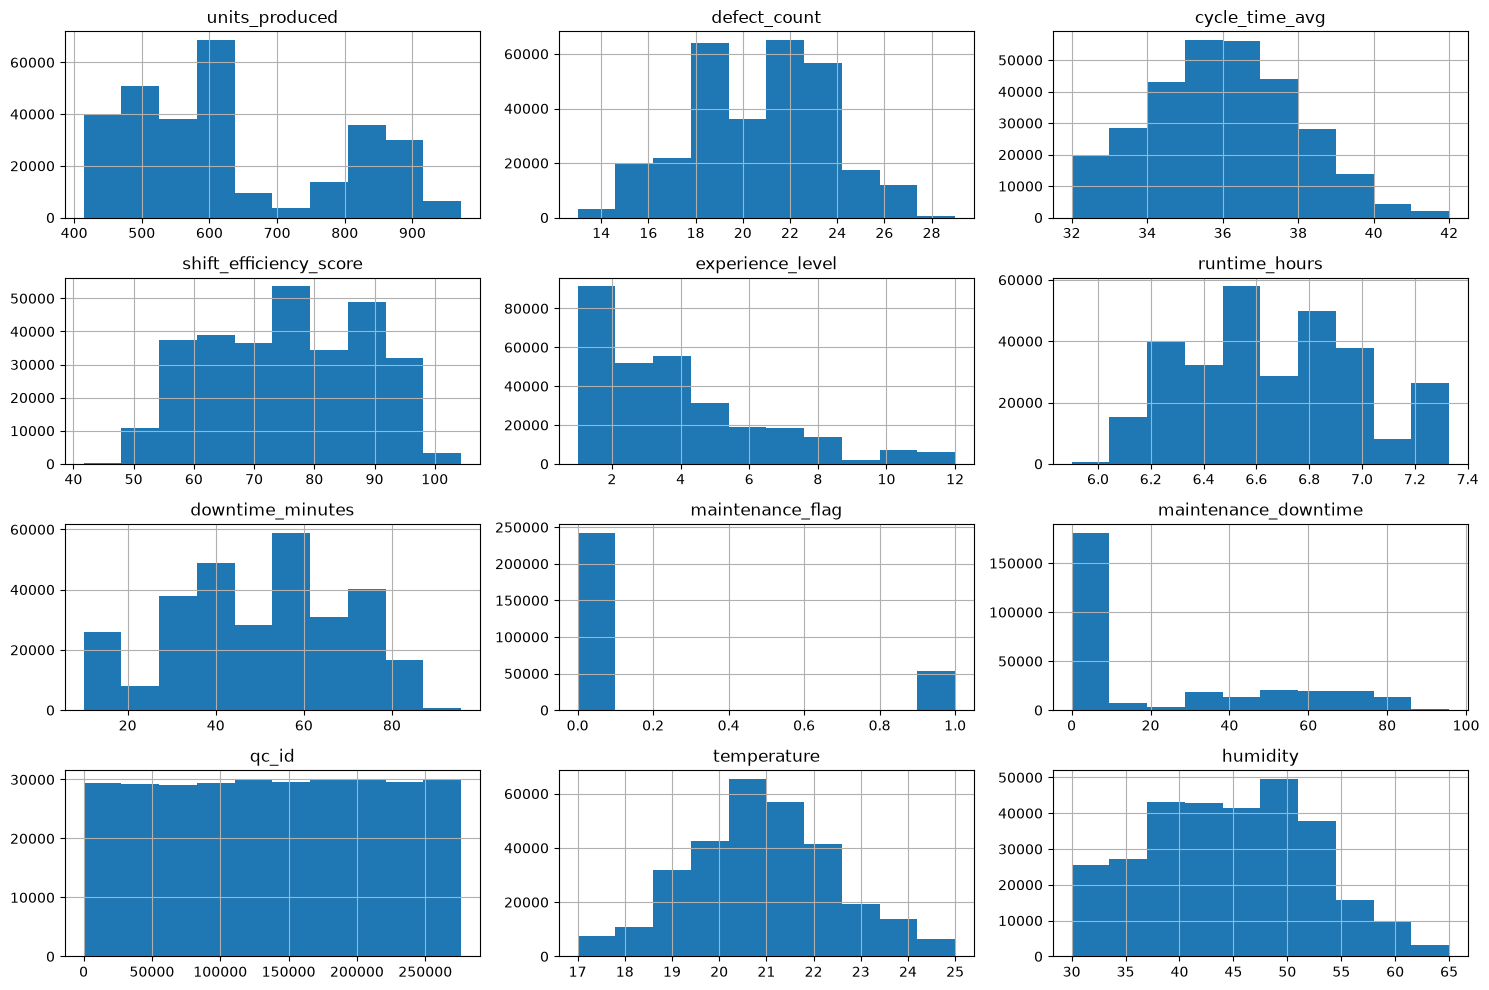

In [22]:
numerical_col= [
    "units_produced", "defect_count", "cycle_time_avg", "shift_efficiency_score","experience_level",
    "runtime_hours","downtime_minutes","maintenance_flag","maintenance_downtime", "qc_id","temperature", "humidity"
]

shift_data[numerical_col].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

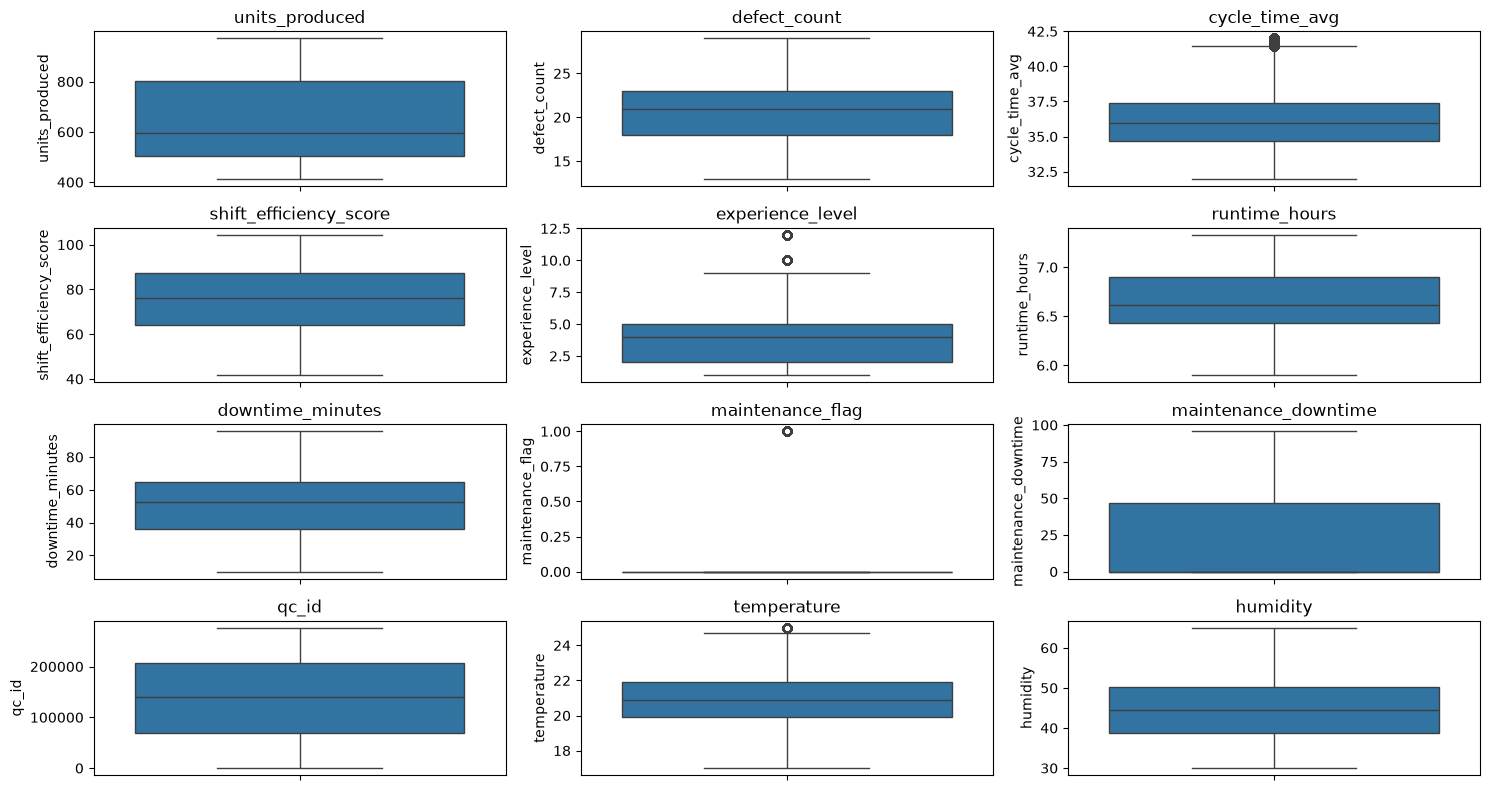

In [24]:
# using boxplot to check for outliers
plt.figure(figsize=(15, 8))

for i, columns in enumerate(numerical_col):
    plt.subplot(4, 3, i+1)
    sns.boxplot(shift_data[columns])
    plt.title(columns)

plt.tight_layout()
plt.show()

In [26]:
## categorical variable analysis
categorical_col=[
    "shift_name", "skill_category", "machine_status", "issue_type","defect_type","severity", "inspection_result"
]
for columns in categorical_col:
    print("value counts for each categorical columns")
    print(shift_data[columns].value_counts())

value counts for each categorical columns
shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
value counts for each categorical columns
skill_category
Intermediate    161685
Junior           56638
Senior           54664
Expert           23347
Name: count, dtype: int64
value counts for each categorical columns
machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
value counts for each categorical columns
issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
value counts for each categorical columns
defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
value counts for each categorical columns
severity
Minor       207323
Major        74329
Critical     14682
Name: count, dtype: int64
value counts for each categorical c

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

## categorical variable analysis
categorical_col=[
    "shift_name", "skill_category",
    "machine_status", "issue_type",
    "defect_type","severity", "inspection_result", "experience_level"
]

fig, axes =plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_col):
    counts = shift_data[col].value_counts().reset_index()
    counts.columns = [col, 'counts']

    sns.barplot(data=counts, x=col, y='counts', palette = 'coolwarm', ax = axes[i])

    axes[i].tick_params(axis='x', rotation = 45)
    axes[i].set_title(f"distribution counts for {col}", fontsize=16, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('counts')

plt.tight_layout
plt.show()